
 NSE STOCK STRATEGY ANALYZER
--------------------------------


Enter NSE stock symbol (example: RELIANCE, TCS, INFY, LT):  LTF


[*********************100%***********************]  1 of 1 completed
C:\Users\kusha\AppData\Local\Temp\ipykernel_25920\2837870720.py:102: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_profit_loss, subset=["Returns", "Strategy_Returns"])
C:\Users\kusha\AppData\Local\Temp\ipykernel_25920\2837870720.py:103: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(highlight_signal, subset=["Signal"])


Price,Close,MA50,MA200,Signal,Returns,Strategy_Returns,Cumulative_Strategy
Ticker,LTF.NS,,,,,,
Date,,,,,,,
2023-12-01 00:00:00,146.575000,132.238000,110.783000,1,0.019000,0.019000,1.593000
2023-12-04 00:00:00,149.341000,132.752000,111.083000,1,0.019000,0.019000,1.623000
2023-12-05 00:00:00,150.021000,133.317000,111.384000,1,0.005000,0.005000,1.631000
2023-12-06 00:00:00,151.331000,133.952000,111.686000,1,0.009000,0.009000,1.645000
2023-12-07 00:00:00,150.263000,134.539000,111.991000,1,-0.007000,-0.007000,1.633000
2023-12-08 00:00:00,149.293000,135.113000,112.288000,1,-0.006000,-0.006000,1.623000
2023-12-11 00:00:00,148.807000,135.687000,112.580000,1,-0.003000,-0.003000,1.618000
2023-12-12 00:00:00,147.982000,136.196000,112.868000,1,-0.006000,-0.006000,1.609000



 Strategy Final Return: 1.74
 Max Drawdown: 0.58


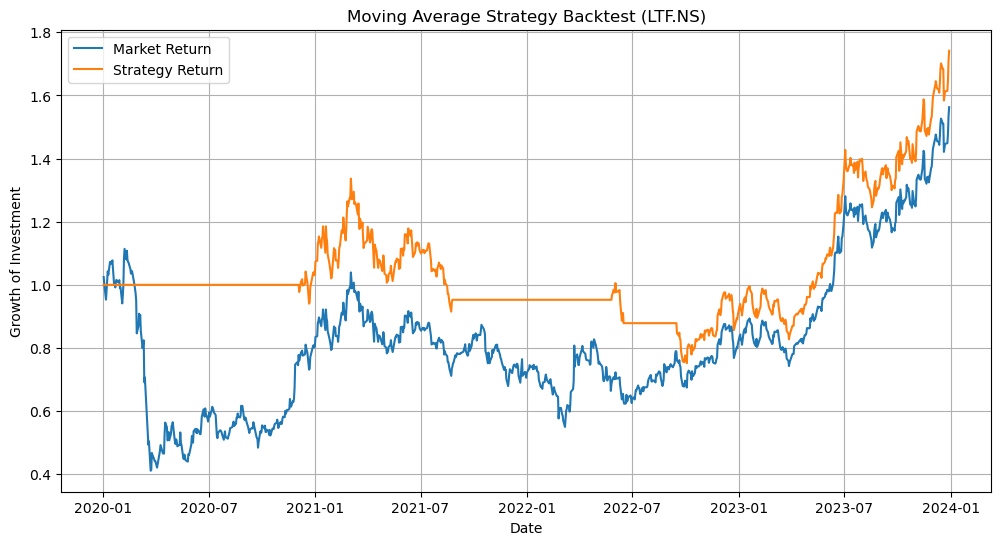

In [3]:
# ================================================================
# NSE STOCK MOVING AVERAGE STRATEGY BACKTEST
# Author: Kushal
# Description:
# Fetch NSE stock data, apply 50/200 MA strategy,
# show colored dataframe + performance + graph
# ================================================================

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ================================================================
# FUNCTION 1: FETCH STOCK DATA
# ================================================================
def fetch_stock_data(symbol: str) -> pd.DataFrame:
    """
    Downloads historical stock data for given NSE symbol
    """

    stock_symbol = symbol.upper().strip() + ".NS"
    print(f"\n Downloading data for: {stock_symbol}")

    data = yf.download(stock_symbol, start="2020-01-01", end="2024-01-01")

    if data.empty:
        print(" Invalid stock symbol. Please run again.")
        return None

    return data


# ================================================================
# FUNCTION 2: APPLY TRADING STRATEGY
# ================================================================
def apply_strategy(data: pd.DataFrame) -> pd.DataFrame:
    """
    Applies moving average crossover strategy
    """

    # Moving averages
    data["MA50"] = data["Close"].rolling(window=50).mean()
    data["MA200"] = data["Close"].rolling(window=200).mean()

    # Buy signal (1 = Buy, 0 = No buy)
    data["Signal"] = 0
    data.loc[data.index[50:], "Signal"] = (
        data["MA50"][50:] > data["MA200"][50:]
    ).astype(int)

    # Daily returns
    data["Returns"] = data["Close"].pct_change()

    # Strategy returns
    data["Strategy_Returns"] = data["Returns"] * data["Signal"].shift(1)

    # Cumulative returns
    data["Cumulative_Market"] = (1 + data["Returns"]).cumprod()
    data["Cumulative_Strategy"] = (1 + data["Strategy_Returns"]).cumprod()

    return data


# ================================================================
# FUNCTION 3: DISPLAY COLORED DATAFRAME + METRICS
# ================================================================
def show_performance(data: pd.DataFrame):
    """
    Displays clean colored dataframe and performance metrics
    """

    display_df = data[
        [
            "Close",
            "MA50",
            "MA200",
            "Signal",
            "Returns",
            "Strategy_Returns",
            "Cumulative_Strategy",
        ]
    ].copy().round(3).tail(20)

    # ---------- Coloring functions ----------
    def color_profit_loss(val):
        if val > 0:
            return "color: green; font-weight: bold"
        elif val < 0:
            return "color: red; font-weight: bold"
        return "color: black"

    def highlight_signal(val):
        if val == 1:
            return "background-color: #d4f7d4"  # light green
        return "background-color: #f7d4d4"  # light red

    # ---------- Apply styling ----------
    styled_df = (
        display_df.style
        .applymap(color_profit_loss, subset=["Returns", "Strategy_Returns"])
        .applymap(highlight_signal, subset=["Signal"])
        .set_caption(" Moving Average Strategy Data (Last 20 Days)")
        .set_table_styles(
            [
                {"selector": "th", "props": [("font-size", "12pt"), ("text-align", "center")]},
                {"selector": "td", "props": [("text-align", "center")]},
                {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "bold")]}
            ]
        )
    )

    display(styled_df)

    # ---------- Performance metrics ----------
    total_return = data["Cumulative_Strategy"].iloc[-1]
    max_drawdown = (
        data["Cumulative_Strategy"].cummax() - data["Cumulative_Strategy"]
    ).max()

    print("\n Strategy Final Return:", round(total_return, 2))
    print(" Max Drawdown:", round(max_drawdown, 2))


# ================================================================
# FUNCTION 4: PLOT GRAPH
# ================================================================
def plot_graph(data: pd.DataFrame, symbol: str):
    """
    Plots market vs strategy performance
    """

    plt.figure(figsize=(12, 6))
    plt.plot(data["Cumulative_Market"], label="Market Return")
    plt.plot(data["Cumulative_Strategy"], label="Strategy Return")

    plt.title(f"Moving Average Strategy Backtest ({symbol.upper()}.NS)")
    plt.xlabel("Date")
    plt.ylabel("Growth of Investment")
    plt.legend()
    plt.grid(True)
    plt.show()


# ================================================================
# MAIN FUNCTION
# ================================================================
def main():
    """
    Main execution program
    """

    print("\n NSE STOCK STRATEGY ANALYZER")
    print("--------------------------------")

    stock_symbol = input(
        "Enter NSE stock symbol (example: RELIANCE, TCS, INFY, LT): "
    )

    stock_data = fetch_stock_data(stock_symbol)

    if stock_data is not None:
        stock_data = apply_strategy(stock_data)
        show_performance(stock_data)
        plot_graph(stock_data, stock_symbol)


# ================================================================
# RUN PROGRAM
# ================================================================
if __name__ == "__main__":
    main()